In [20]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import softmax
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import TextVectorization

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

In [2]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [3]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
dev = tf.config.list_physical_devices()
print('Physical Devices : ', dev)

#tf.config.set_visible_devices(dev[0])
#tf.config.set_visible_devices(dev[1])
dev = tf.config.list_logical_devices()
print('Available Devices : ', dev)

Physical Devices :  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Available Devices :  [LogicalDevice(name='/device:CPU:0', device_type='CPU'), LogicalDevice(name='/device:GPU:0', device_type='GPU')]


I0000 00:00:1750694470.372404   12178 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


# Chapter 12: Generative Deep Learning

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

Generative AI and using deep learning architectures is particulary popular right now,
though I personally agree with the assessment that it "has fed a (not so) short-lived hype
wave worthy of the most torrid AI summer.  In any case, the promise of generative AI is that
it can be used as a tool to augment human capabilities, so more generative augmentive intelligence
rather than artifical general intelligence.

In this section we will look at some of the basic mechanisms and architectures for building generative
systems using deep learning networks.  We will look at generating text and images, and
what autoencoders and GAN networks are all about.

Code from previous units needed in this notebook.

In [27]:
class MyTfNotEqualLayer(layers.Layer):
    def call(self, inputs):
        return tf.math.not_equal(inputs, 0)

class PositionalEmbedding(layers.Layer):
    """Example implementation of learning position embedding vectors as a layer.
    """
    
    def __init__(self, sequence_length, input_dim, output_dim, **kwargs):
        """Override base class constructor to add in additional parameters
        needed for this layer.

        Parameters
        ----------
        sequence_length : int
            A downside of position embeddings is that the sequence length needs to be known in advance.
        input_dim : int
        output_dim : int
            The number of input dimensions coming into this embedding layer, and the number of output dimensions to
            create and output.
        """
        # chain superclass constructor first
        super().__init__(**kwargs)

        # prepare an embedding layer for the token indices
        self.token_embeddings = layers.Embedding(input_dim=input_dim, output_dim=output_dim)

        # add another embedding layer for the token positions
        self.position_embeddings = layers.Embedding(input_dim=sequence_length, output_dim=output_dim)
        
        self.sequence_length = sequence_length
        self.input_dim = input_dim
        self.output_dim = output_dim
    
    def call(self, inputs):
        """Computation is handled by call member method

        Parameters
        ----------
        inputs : ndarray (num_samples, sequence_length, input_dim)
            The inputs for Keras layers always have some number of samples.  In our example
            we use token sequences of sequence_length where each token is embeded in an
            embedding space of input_dim number of dimensions.        
        """
        # positions is a sequence from 0,1,...length-1 of the inputs
        length = tf.shape(inputs)[-1]
        positions = tf.range(start=0, limit=length, delta=1)

        # perform embedding learning for the tokens from the input
        embedded_tokens = self.token_embeddings(inputs)

        # perform embedding learning of positions
        embedded_positions = self.position_embeddings(positions)

        # add both embedding vectors of token and position embeddings together to be returned
        return embedded_tokens + embedded_positions

    def compute_mask(self, inputs, mask=None):
        """like embedding layer, this layer should be able to generate a mask so we can ignore
        padding 0s in the inputs.  The compute_mask method will be called automatically by the
        framework and the mask will get propagated to the next layer

        Parameters
        ----------
        inputs : ndarray (num_samples, sequence_length, input_dim)
            The inputs to generate embedding masks for.       
        """
        # a little kludgy, API has changed here apparently, we will have to return a laye that wraps this
        # tensorflow function
        return MyTfNotEqualLayer()(inputs)

    def get_config(self):
        """Implement serialization so that we can save the model. Should return a
        python dict that contains values of the constructor arguments used to create the
        layer.  So we chain the super class get_config, then add in our 3 additional
        constructor arguments.
        """
        config = super().get_config()
        config.update({
            "output_dim": self.output_dim,
            "sequence_length": self.sequence_length,
            "input_dim": self.input_dim,
        })
        return config

In [28]:
class TransformerDecoder(layers.Layer):
    """Implementaiton of custom TransformerDecoder.  Similar to the encoder, but an extra MutliHeadAttention
    is added to receive the output from the encoder.  Thus in the second MultiHeadAttention we can
    use the target sentence as an attention "query" and source sequence will be both keys and values.
    """
    
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        """Override base constructor to support TransformerDecoder initialization parameters

        Parameters
        ----------
        embed_dim : int
            The size of the embedding dimension, e.g. the size of the input sample token vectors
        dense_dim : int
            The size of the inner dense layer for the Dense projectios of the output of the MultiHead
        num_heads : int
            The number of independent heads (features) in the MultiHeadAttention to use
        """
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads

        # create initial multihead attention layer to get target inputs and
        # compute neural attention on them
        self.attention_1 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)

        # second multihead attention computes attention from encoder source result and
        # the target attention
        self.attention_2 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)

        # same set of dense layers for encoding and projecting back to output embedding dimension
        self.dense_proj = keras.Sequential(
            [layers.Dense(dense_dim, activation="relu"),
             layers.Dense(embed_dim),]
        )

        # an extra normalizaiton is added so there is now one after each multihead attention and before
        # the final output
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.layernorm_3 = layers.LayerNormalization()
        # this may answer my previous question, this was not shown in previous encoder model
        self.supports_masking = True

    def get_causal_attention_mask(self, inputs):
        """The TransformerDecoder is order-agnostic, we must take into account
        that it has information about th efuture.  We must implement causal padding.
        Only information from tokens 0..N in the target sequence should be used
        when generating target N+1

        Parameters
        ----------
        inputs : ndarray
        inputs : ndarray (batch_size, sequence_length, embedding_dim)
            The inputs for Keras layers always have some number of samples.  In our example
            we use token sequences where each token is embeded in an embedding space of embedding_dim
            number of dimensions.        
        """
        # infer the batch size and sequence length from inputs
        input_shape = tf.shape(inputs)
        batch_size, sequence_length = input_shape[0], input_shape[1]

        
        i = tf.range(sequence_length)[:, tf.newaxis]
        j = tf.range(sequence_length)

        # generate a matrix of shape (sequence_length, sequence_length) with 1's in one half and
        # 0's in the other
        mask = tf.cast(i >= j, dtype="int32")
        mask = tf.reshape(mask, (1, input_shape[1], input_shape[1]))
        
        # replicate it along the batch axis to get a matrix of shape
        # (batch_size, sequence_length, sequence_length)
        mult = tf.concat(
            [tf.expand_dims(batch_size, -1),
             tf.constant([1, 1], dtype=tf.int32)], axis=0)
        return tf.tile(mask, mult)

    def call(self, inputs, encoder_outputs, mask=None):
        """Computation goes in call member function.

        Parameters
        ----------
        inputs : ndarray (num_samples, max_tokens, embedding_dim)
            The inputs for Keras layers always have some number of samples.  In our example
            we use token sequences where each token is embeded in an embedding space of embedding_dim
            number of dimensions.
        encoder_outputs : ndarray (num_samples, max_tokens, embedding_dim)?
            We are expecting 2 input paths, this will receive the outputs from the encoder
            to inject into our second multihead attention layer.
        """
        # get the causal mask and combine with the mask into this
        # TransformerEncoder.  causal_mask masks out future events and
        # padding_mask masks out sequences that are short
        causal_mask = self.get_causal_attention_mask(inputs)
        if mask is not None:
            padding_mask = tf.cast(mask[:, tf.newaxis, :], dtype="int32")
            padding_mask = tf.minimum(padding_mask, causal_mask)
        else: # bug in book, need to ensure this is set
            padding_mask = mask

        # first multihead attention, gets target inputs
        attention_output_1 = self.attention_1(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=causal_mask)

        # output of first attention is then normalized, there is a residual
        # connection so we get raw inputs and attention output combined here
        attention_output_1 = self.layernorm_1(inputs + attention_output_1)

        # second multihead attention uses the target outputs for the query
        # and the value and key come from the encoder outputs
        attention_output_2 = self.attention_2(
            query=attention_output_1,
            value=encoder_outputs,
            key=encoder_outputs,
            attention_mask=padding_mask,
        )

        # again normalize output of second attention, and again use a residual
        # connection and combine here
        attention_output_2 = self.layernorm_2(
            attention_output_1 + attention_output_2)

        # the output from combined attention is fed into the dense layer
        proj_output = self.dense_proj(attention_output_2)

        # final normalization before returning result, again a residual
        # connection around the dense layers is combined here
        return self.layernorm_3(attention_output_2 + proj_output)

    def get_config(self):
        """Implement serialization so that we can save the model. Should return a
        python dict that contains values of the constructor arguments used to create the
        layer.  So we chain the super class get_config, then add in our 3 additional
        constructor arguments.
        """
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dense_dim": self.dense_dim,
        })
        return config

## 12.1 Text Generation

### 12.1.2 How do you Generate Sequence Data?

### 12.1.3 The Importance of the Sampling Strategy

In order to control the amount of stochasticity in the sampling process, we’ll introduce
a parameter called the **softmax temperature**, which characterizes the entropy of the
probability distribution used for sampling: it characterizes how surprising or predictable
the choice of the next word will be. Given a temperature value, a new probability
distribution is computed from the original one (the softmax output of the model) by
reweighting it in the following way.

In [4]:
def reweight_distribution(original_distribution, temperature=0.5):
    """Given a softmax probability distribution, reweight the probabilities
    using a temperature variable.  Temperature 0 = greedy sampling, temperature
    1 = original distribution, Temperature > 1, more randomness until
    completely uniform distribution.

    Parameters
    ----------
    original_distribution : ndarray 
        Vector of probability over a vocabulary, probability must sum to 1.0
    temperature : float
        Factor quantifying the entropy of the output distribution

    Returns
    -------
    new_distribution : ndarray
        A reweighted version of the original distribution.
    """
    distribution = np.log(original_distribution) / temperature
    distribution = np.exp(distribution)
    # sum may longer be 1.0, so divide by the sum to obtain new probability
    # distribution that sums to 1.0
    return distribution / np.sum(distribution)

Lets recreate the figures from the text.  Books description of the reweight function seems a bit off.
A temperature near 0 will give a basically greedy sampling.  But temperature 1 ends up with the same
distribution.  Need temperatures higher than 1 to make distribution more random, anything
less than 1 results in more deterministic sample.

In [12]:
# example approximate original distribution shown in text
original_distribution = np.array([0.11, 0.23, 0.04, 0.03, 0.15, 0.05, 0.06, 0.02, 0.12, 0.19])
#original_distribution = softmax(original_distribution)
print(original_distribution)
print(original_distribution.sum())

[0.11 0.23 0.04 0.03 0.15 0.05 0.06 0.02 0.12 0.19]
1.0


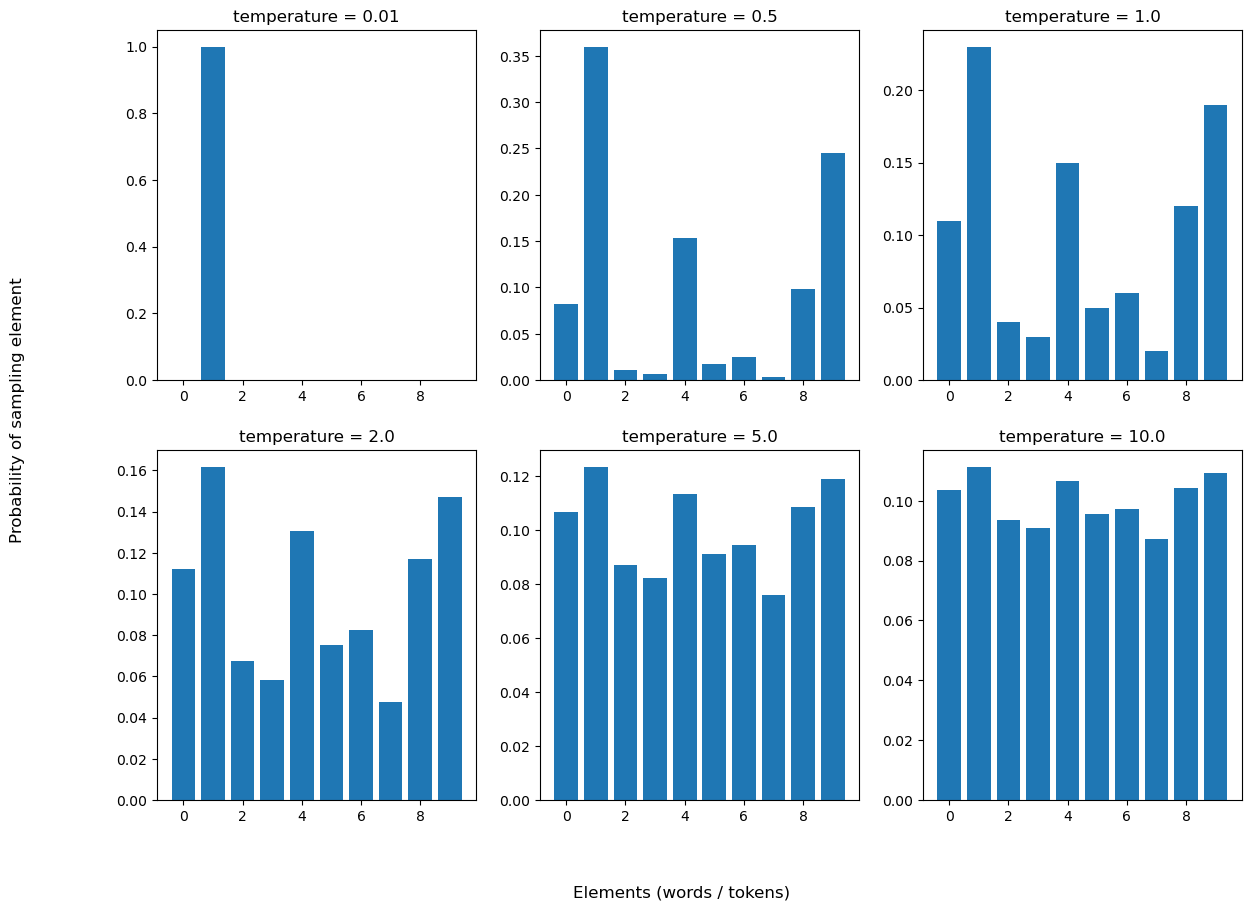

In [13]:
x = np.arange(10)
temperatures = [0.01, 0.5, 1.0, 2.0, 5.0, 10.0]
fig = plt.figure(figsize=(14,10))
for idx, temperature in zip(range(1,7), temperatures):
    new_dist = reweight_distribution(original_distribution, temperature)
    plt.subplot(2, 3, idx)
    plt.bar(x, new_dist)
    plt.title(f"temperature = {temperature}")
fig.supylabel('Probability of sampling element')
fig.supxlabel('Elements (words / tokens)');

### 12.1.4 Implementing Text Generation with Keras

Let’s put these ideas into practice in a Keras implementation. The first thing you need
is a lot of text data that you can use to learn a language model. You can use any sufficiently
large text file or set of text files—Wikipedia, The Lord of the Rings, and so on.

In this example, we’ll keep working with the IMDB movie review dataset from the
last chapter, and we’ll learn to generate never-read-before movie reviews.

#### Preparing the data

As before download the IMDB data, if you don't still have it:

```
vscode ➜ /workspaces/nndl/data (main) $ wget https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz

vscode ➜ /workspaces/nndl/data (main) $ tar -xf aclImdb_v1.tar.gz
```

There are two subfolders in the extracted `aclImdb` directory named `test` and `train`.  We had previously by hand randomly
selected some of the `test` data files and moved them to a `val` subdirectory.  Each of the `test`, `train` and `val`
subdirectory (if you have it) contain `neg` and `pos` subdirectories beneath them with our binary classification
negative and positive reviews.

```
vscode ➜ /workspaces/nndl/data (main) $ tree -d aclImdb/
aclImdb/
├── test
│   ├── neg
│   └── pos
├── train
│   ├── neg
│   └── pos
└── val
    ├── neg
    └── pos
```

**Note**: The following loads 100k text files, so takes a bit of time...


In [23]:
# label mode is none will cause data to be read without neg/pos labels
# in fact, subdirectory is ignored and all .txt files are batched in this
# dataset that are found under the aclImdb subdirectory
dataset = keras.utils.text_dataset_from_directory(
    directory='../data/aclImdb',
    label_mode=None,
    batch_size=256
)

# strip the <br /> HTML tag that occurs in many of the reviews.  This did not matter much for
# text classification, but we wouldn't want to generate <br /> tags in this example!
dataset = dataset.map(lambda x: tf.strings.regex_replace(x, '<br />', ' '))

Found 50006 files.


In [24]:
for x in dataset:
    print(type(x))
    print(x.shape)
    print(x[0])
    break

<class 'tensorflow.python.framework.ops.EagerTensor'>
(256,)
tf.Tensor(b"A movie about dealing with the problems with growing up and being true to yourself, Blue Juice is mind candy for those who like surfing and Cornwall. Sean Pertwee is the real star of this film, while the more famous Catherine Zeta Jones plays his girlfriend and Ewan Mcgregor plays his drug addicted pal.  For those who don't like surfing or Cornwall in the slightest, you'll find that it takes a long time before the movie even hints at being interesting. The beginning is slow and spends too much time on long shots of only slightly interesting landscapes. Plus too many main characters leads to most of them being one dimensional. The plot is an interesting idea but because of the shallow characters you have no idea why they act in the situations they're put in.  Only Ewan, Sean and Catherine's characters make this a film worth being on videotape, which is why it was only released on videotape in the US after Ewan and 

Now let's define a `TextVectorization` layer to do normalization, tokenization and compute the vocabulary
we'll be working with.  We'll only use the first `sequence_length` words of each review, and will keep only the
most `vocab_size` common words in the vocabulary.  Otherwise we will use standard normalization (strip
punctuation and make lowercase) and tokenization (tokenize on white space).

In [25]:
# only use top 15,000 most common words and limit reviews to first 100
# words
sequence_length = 100
vocab_size = 15000

text_vectorization = TextVectorization(
    max_tokens=vocab_size,
    # we will return integer word indexes 
    output_mode="int",
    # we'll work with inputs and targets of length 100 (but since we will
    # offset targets by 1 the model will actually see sequences of length 99
    output_sequence_length=sequence_length,
)

text_vectorization.adapt(dataset)

Let's use the layer to create a language modeling dataset where input samples are
vectorized texts, and corresponding targets are the same texts offset by one word.

In [26]:
def prepare_lm_dataset(text_batch):
    """Converts a batch of texts (strings) ot a batch of integer sequences.
    """
    vectorized_sequences = text_vectorization(text_batch)

    # create inputs by cutting of the last word of the sequence
    x = vectorized_sequences[:, :-1]
    # create targets by offsetting the sequences by 1
    y = vectorized_sequences[:, 1:]
    return x, y

lm_dataset = dataset.map(prepare_lm_dataset, num_parallel_calls=4)

#### A Transformer-based sequence-to-sequence model

We’ll use a sequence-to-sequence model: we’ll feed sequences
of N words (indexed from `0` to `N`) into our model, and we’ll predict the sequence offset
by one (from `1` to `N+1`). We’ll use causal masking to make sure that, for any `i`, the model
will only be using words from `0` to `i` in order to predict the word `i + 1`. This means that
we’re simultaneously training the model to solve `N` mostly overlapping but different
problems: predicting the next words given a sequence of `1 <= i <= N` prior words.

When you’re doing text generation,
there is no source sequence: you’re just trying to predict the next tokens in the target
sequence given past tokens, which we can do using only the decoder.

Let’s implement our model, we're going to reuse the building blocks we created
in the previous unit: `PositionalEmbedding` and `TransformerDecoder`.
(included at top of notebook).

**TODO**: should extract more general code/utils and put into `src/nndl.py`

In [29]:
embed_dim = 256
latent_dim = 2048
num_heads = 2

inputs = keras.Input(shape=(None,), dtype="int64")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(inputs)
x = TransformerDecoder(embed_dim, latent_dim, num_heads)(x, x)
outputs = layers.Dense(vocab_size, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(loss="sparse_categorical_crossentropy", optimizer="rmsprop")

### 12.1.5 A Text-generation Callback with Variable-temperature Sampling

We’ll use a callback to generate text using a range of different temperatures after
every epoch. This allows you to see how the generated text evolves as the model
begins to converge, as well as the impact of temperature in the sampling strategy.
To seed text generation, we’ll use the prompt “this movie”: all of our generated texts
will start with this.

In [34]:
# the text-generation callback
tokens_index = dict(enumerate(text_vectorization.get_vocabulary()))

def sample_next(predictions, temperature=1.0):
    """Implement variable temperature sampling from the probability distribution.
    """
    predictions = np.asarray(predictions).astype("float64")
    predictions = np.log(predictions) / temperature
    exp_preds = np.exp(predictions)
    predictions = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, predictions, 1)
    return np.argmax(probas)

class TextGenerator(keras.callbacks.Callback):
    def __init__(self, prompt, generate_length, temperatures=(1.,), print_freq=1):
        """Constructor for callback to be used in text generation example.

        Parameters
        ----------
        prompt : str
            The initial prompt string to use
        generate_length : int
            How many words to generate
        temperatures : list like
            Range of temperatures to use for sampling
        print_freq : int
            The epoch mod to use to determine how often callback reports
        """
        self.prompt = prompt
        self.generate_length = generate_length
        self.temperatures = temperatures
        self.print_freq = print_freq

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.print_freq != 0:
            return
        for temperature in self.temperatures:
            print()
            print("== Generating with temperature", temperature)
            sentence = self.prompt
            for i in range(self.generate_length):
                tokenized_sentence = text_vectorization([sentence])
                predictions = self.model(tokenized_sentence)
                # NOTE: bug in book, wasn't passing in the temperature parameter here for
                # sampling next token
                next_token = sample_next(predictions[0, i, :], temperature)
                sampled_token = tokens_index[next_token]
                sentence += " " + sampled_token
            print(sentence)

In [35]:
# we'll prompt the generator with these words and we'll use a diverse range
# of temperatures to sample text, to demonstrate the effect of temperature on
# text generation
prompt = "this movie"
text_gen_callback = TextGenerator(
    prompt,
    generate_length=50,
    temperatures=(0.2, 0.5, 0.7, 1., 1.5))

We have all of the pieces that we need to try and fit the model now.

In [36]:
model.fit(lm_dataset, epochs=200, callbacks=[text_gen_callback])

Epoch 1/200
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - loss: 5.3444== Generating with temperature 0.2
This movie movie is is a a great very movie good that and is the the acting story is is the a movie very is good very and good the but acting the is movie very is good a and good the and acting the is acting very is good very and
== Generating with temperature 0.5
This movie is was very a well [UNK] done and with im this not is that even the the acting first is movie a and great the film story is and very a good little movie bit but of it the is acting a is look not cool even and the the
== Generating with temperature 0.7
This movie is was the a worst six movie of and the entertaining plot it is is not really funny very lovable well and done crappy it i isnt feel that as dull he and is it worth is it so out if with you no have acting a was movie a
== Generating with temperature 1.0
This movie is is no a more kind count of it the and acting not from make wes it had seems lots to of me

KeyboardInterrupt: 

As you will see after 200 epochs, low temperature will often give boring and repetitive text and can
sometimes be stuck in a loop.

With higher temperatures, the text becomes more interesting, surprising and at times seemingly creative.

With a very high temperature the local structure starts to break down and the output begins to look incoherent.

A good generation temperature is probably somewhere around 0.7 here.

Note that by training a bigger model, longer, on more data, you can achieve generated
samples that look far more coherent and realistic than this one—the output
of a model like GPT is a good example of what can be done with language models. 
GPT is effectively the same thing as what we trained in this example, but with
a deep stack of Transformer decoders and a huge training corpus.

But don’t
expect to ever generate any meaningful text, other than through random chance
and the magic of your own interpretation: all you’re doing is sampling data from a
statistical model of which words come after which words. Language models are all
form and no substance.

## Summary

<font color='blue'>
    
- You can generate discrete sequence data by training a model to predict the next
  token(s), given previous tokens.
- In the case of text, such a model is called a language model. It can be based on
  either words or characters.
- Sampling the next token requires a balance between adhering to what the
  model judges likely, and introducing randomness.
- One way to handle this is the notion of softmax temperature. Always experiment
  with different temperatures to find the right one.